# Chapter 4 — SIR Model (Permanent Removal)

**Modeling Social Behavior** | Smaldino

---

### What this notebook does

We build the **SIR (Susceptible --> Infected --> Removed)** model — the final and most  
famous model in this chapter. It is a direct extension of the SIS model with one  
crucial difference: **recovery now confers permanent immunity**.

Recovered agents enter the **Removed (R)** state. They can neither be infected again  
nor transmit the contagion. This pool of immune individuals is what makes the epidemic  
burn itself out even when susceptible agents still remain.

### The three states

| State | Meaning | Can be infected? | Can infect others? |
|---|---|---|---|
| **S** — Susceptible | Uninfected, no immunity | ✅ Yes | ❌ No |
| **I** — Infected | Currently infected | N/A | ✅ Yes |
| **R** — Removed | Recovered, permanently immune | ❌ No | ❌ No |

### The key new outcome: epidemic burnout

Because the R pool grows over time and can never shrink, the epidemic **always ends**  
not because everyone is infected, but because the density of susceptibles eventually  
drops low enough that new infections can't keep pace with recoveries.  
This is fundamentally different from both SI (universal saturation) and SIS (equilibrium).

### The `remove-recovered?` switch

The book's model has a boolean switch: when `remove-recovered? = True`, recovered agents  
become immune (SIR). When `remove-recovered? = False`, they return to susceptible (SIS).  
We implement this as a parameter `remove_recovered` in our Python model, letting us  
directly compare SIS and SIR dynamics from the same codebase.


---
## 1. Imports and Setup


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from mesa import Agent, Model
from mesa.space import ContinuousSpace
from mesa.datacollection import DataCollector

np.random.seed(42)
print("All imports successful.")


All imports successful.


---
## 2. The Agent Class

The SIR agent has a new agent-level variable: `immune`.  
When an agent recovers and `remove_recovered = True`, `immune` is set to `True`  
and the agent is permanently excluded from both infection and transmission.

### Variable types
| Variable | Type | Description |
|---|---|---|
| `self.infected` | Agent-level | True if currently infected |
| `self.immune` | Agent-level | True if permanently recovered (Removed state) |
| `self.newly_infected` | Agent-level | Blocks same-step recovery (same guard as SIS) |
| `self.heading` | Agent-level | Current movement direction (radians) |

### State logic
An agent's full state at any moment:

| `infected` | `immune` | Interpretation |
|---|---|---|
| False | False | Susceptible (S) |
| True | False | Infected (I) |
| False | True | Removed / immune (R) |
| True | True | Impossible — immune agents cannot be infected |


In [2]:
class SIRAgent(Agent):
    '''
    A single agent in the SIR contagion model.

    Agent-level variables:
        infected        (bool) -- True if currently infected
        immune          (bool) -- True if permanently immune (Removed state)
        newly_infected  (bool) -- Blocks recovery in the same step as infection
        heading         (float) -- Current movement direction in radians
    '''

    def __init__(self, model):
        super().__init__(model)

        # AGENT VARIABLE: infection status
        self.infected = False

        # AGENT VARIABLE: immunity status
        # Once set to True (after recovery when remove_recovered=True),
        # this agent is permanently excluded from the susceptible pool.
        self.immune = False

        # AGENT VARIABLE: newly_infected flag — same guard as the SIS model.
        # Prevents an agent from being infected and recovering in the same step.
        self.newly_infected = False

        # AGENT VARIABLE: movement heading
        self.heading = self.random.uniform(0, 2 * np.pi)

    def step(self):
        # Step 1: Clear the newly_infected flag from last step
        self.newly_infected = False

        # Step 2: Try to become infected (only if susceptible — not infected, not immune)
        self._try_infection()

        # Step 3: Try to recover (only if infected and not newly infected this step)
        self._try_recovery()

        # Step 4: Move
        self._move()

    # ------------------------------------------------------------------
    # INFECTION
    # ------------------------------------------------------------------
    def _try_infection(self):
        '''
        Infection works identically to the SIS model, but with one extra guard:
        immune agents (state R) are completely excluded from infection.

        Combined probability formula (same as before):
            Pr(infection) = 1 - (1 - tau)^n * (1 - alpha)
        '''
        # Skip if already infected OR permanently immune
        if self.infected or self.immune:
            return

        # LOCAL VARIABLE: neighbors — agents within infection radius
        neighbors = self.model.space.get_neighbors(
            self.pos, self.model.infection_radius, include_center=False
        )

        # LOCAL VARIABLE: n_infected — count of infected (not immune) neighbors
        n_infected = sum(1 for nb in neighbors if nb.infected)

        p_escape_neighbors   = (1 - self.model.tau) ** n_infected
        p_escape_spontaneous = (1 - self.model.alpha)
        p_infection = 1 - (p_escape_neighbors * p_escape_spontaneous)

        if self.random.random() < p_infection:
            self.infected = True
            self.newly_infected = True

    # ------------------------------------------------------------------
    # RECOVERY — the critical difference from SIS
    # ------------------------------------------------------------------
    def _try_recovery(self):
        '''
        Infected agents recover with probability gamma per step.

        What happens on recovery depends on the model parameter remove_recovered:
          - remove_recovered = False  -->  agent returns to Susceptible (SIS behavior)
          - remove_recovered = True   -->  agent becomes permanently immune (SIR behavior)

        The newly_infected guard is the same as in the SIS model:
        only agents infected in a PREVIOUS step can recover.
        '''
        if self.infected and not self.newly_infected:
            if self.random.random() < self.model.gamma:
                self.infected = False

                # SIR: set immune = True so the agent enters the Removed pool
                # SIS: leave immune = False so the agent returns to susceptible
                if self.model.remove_recovered:
                    self.immune = True

    # ------------------------------------------------------------------
    # MOVEMENT
    # ------------------------------------------------------------------
    def _move(self):
        '''Correlated random walk with toroidal wrapping.'''
        max_turn = np.radians(self.model.turning_angle) / 2
        self.heading += self.random.uniform(-max_turn, max_turn)
        dx = self.model.speed * np.cos(self.heading)
        dy = self.model.speed * np.sin(self.heading)
        self.model.space.move_agent(self, (self.pos[0] + dx, self.pos[1] + dy))


---
## 3. The Model Class

One new global parameter compared to the SIS model: **`remove_recovered`** (boolean).

The DataCollector now tracks **three** time series:
- `proportion_susceptible` — fraction in state S
- `proportion_infected` — fraction in state I
- `proportion_removed` — fraction in state R

The stop condition also changes from SIS: the simulation stops when  
**no infected agents remain** — because with immunity building up, the epidemic  
always ends (unlike SIS where it could persist indefinitely).

### Variable types
| Variable | Type | Description |
|---|---|---|
| `N` | Global | Total number of agents |
| `init_infected` | Global | Seed infections at t=0 |
| `tau` | Global | Transmissibility (τ) |
| `gamma` | Global | Recovery rate (γ) |
| `alpha` | Global | Spontaneous infection rate (default 0) |
| `remove_recovered` | Global | If True: SIR (immunity); if False: SIS (back to susceptible) |
| `infection_radius` | Global | Spatial radius for neighbor detection |
| `speed` | Global | Movement distance per step |
| `turning_angle` | Global | Max heading change per step (degrees) |


In [3]:
class SIRModel(Model):
    '''
    The SIR contagion model. Setting remove_recovered=False gives SIS behavior.

    Global parameters:
        N                (int)   -- total number of agents
        init_infected    (int)   -- seed infections at t=0
        tau              (float) -- transmissibility (per-contact infection probability)
        gamma            (float) -- recovery rate (probability of recovering per step)
        alpha            (float) -- spontaneous infection rate (default 0)
        remove_recovered (bool)  -- True = SIR (permanent immunity); False = SIS
        infection_radius (float) -- spatial radius for neighbor detection
        speed            (float) -- movement distance per step
        turning_angle    (float) -- max heading change per step, in degrees
        width, height    (float) -- size of the 2-D toroidal space
    '''

    def __init__(
        self,
        N=1000,
        init_infected=1,
        tau=0.05,
        gamma=0.01,
        alpha=0.0,
        remove_recovered=True,
        infection_radius=1.0,
        speed=0.5,
        turning_angle=60,
        width=33,
        height=33,
    ):
        super().__init__()

        # ── GLOBAL VARIABLES ──────────────────────────────────────────
        self.N = N
        self.init_infected = init_infected
        self.tau = tau
        self.gamma = gamma
        self.alpha = alpha
        self.remove_recovered = remove_recovered   # True = SIR, False = SIS
        self.infection_radius = infection_radius
        self.speed = speed
        self.turning_angle = turning_angle
        self.running = True

        # ── SPACE ─────────────────────────────────────────────────────
        self.space = ContinuousSpace(width, height, torus=True)

        # ── CREATE AND PLACE AGENTS ───────────────────────────────────
        for _ in range(self.N):
            agent = SIRAgent(self)
            x = self.random.uniform(0, width)
            y = self.random.uniform(0, height)
            self.space.place_agent(agent, (x, y))

        # ── SEED INITIAL INFECTIONS ───────────────────────────────────
        n_seed = min(self.init_infected, self.N)
        seeds = list(self.agents)[:n_seed]
        for agent in seeds:
            agent.infected = True
            agent.newly_infected = False  # seeds are established — eligible for recovery

        # ── DATA COLLECTOR ────────────────────────────────────────────
        # Track all three compartments over time.
        self.datacollector = DataCollector(
            model_reporters={
                "proportion_susceptible": lambda m: sum(
                    1 for a in m.agents if not a.infected and not a.immune
                ) / m.N,
                "proportion_infected": lambda m: sum(
                    1 for a in m.agents if a.infected
                ) / m.N,
                "proportion_removed": lambda m: sum(
                    1 for a in m.agents if a.immune
                ) / m.N,
            }
        )
        self.datacollector.collect(self)

    def step(self):
        '''
        One time step. Stop when no infected agents remain:
        in SIR this means the epidemic has burned out;
        in SIS (remove_recovered=False) this means the outbreak failed.
        '''
        self.agents.shuffle_do("step")
        self.datacollector.collect(self)

        # Stop when no one is infected — epidemic is over
        n_infected = sum(1 for a in self.agents if a.infected)
        if n_infected == 0:
            self.running = False

    def run(self, max_steps=2000):
        '''Run up to max_steps. Returns a pandas DataFrame of recorded data.'''
        for _ in range(max_steps):
            if not self.running:
                break
            self.step()
        return self.datacollector.get_model_vars_dataframe()


---
## 4. The Analytical SIR Model

The SIR model has **three coupled difference equations** — one for each compartment:

$$S_{t+1} = S_t - \tau \frac{I_t}{N} S_t \tag{S}$$

$$I_{t+1} = I_t + \tau \frac{I_t}{N} S_t - \gamma I_t \tag{I}$$

$$R_{t+1} = R_t + \gamma I_t \tag{R}$$

Note that $S_t + I_t + R_t = N$ at all times, agents just flow between compartments.

### How this differs from SIS

In the SIS model, recovered agents went back into S.  
Here, recovered agents accumulate in R permanently.  
As R grows, S shrinks and since new infections require S × I contact,  
the epidemic slows and eventually stops even if S > 0 when it ends.

### The final size: not everyone gets infected

In SIR, the epidemic ends when I = 0, but there will always be some  
susceptibles remaining who were never exposed. The fraction of the population  
that was *never* infected is determined by R₀ and can be calculated analytically 
but the math requires solving a transcendental equation, so we compute it numerically.

### Variables
| Variable | Type | Description |
|---|---|---|
| `S`, `I`, `R` | Local | Counts in each compartment at each step |
| `tau`, `gamma` | Parameters | Transmissibility and recovery rate |
| `N`, `I0` | Parameters | Population size and initial infected count |


In [4]:
def analytical_SIR(N, tau, gamma, I0, n_steps):
    '''
    Numerically solves the three coupled SIR difference equations.

    Equations:
        S_{t+1} = S_t - tau * (I_t / N) * S_t
        I_{t+1} = I_t + tau * (I_t / N) * S_t - gamma * I_t
        R_{t+1} = R_t + gamma * I_t

    Parameters
    ----------
    N       : int   -- total population
    tau     : float -- transmissibility
    gamma   : float -- recovery rate
    I0      : int   -- initial infected count
    n_steps : int   -- number of time steps to compute

    Returns
    -------
    S_prop, I_prop, R_prop : np.ndarray
        Proportions in each compartment at each time step (length n_steps+1).
    '''
    # LOCAL VARIABLES: S, I, R — starting values for the three compartments
    S = float(N - I0)   # everyone except the seeds starts susceptible
    I = float(I0)       # seed infections
    R = 0.0             # no one is immune at the start

    S_list, I_list, R_list = [S], [I], [R]

    for _ in range(n_steps):
        # New infections this step: rate = tau * frequency of infected * count of susceptibles
        new_infections = tau * (I / N) * S

        # Recoveries: a proportion gamma of infected agents recover and become immune
        new_recoveries = gamma * I

        # Update all three compartments simultaneously
        # (use current values for all — this is a simultaneous update, not sequential)
        S_new = S - new_infections
        I_new = I + new_infections - new_recoveries
        R_new = R + new_recoveries

        # Clamp to prevent tiny negative values from numerical precision
        S = max(0.0, S_new)
        I = max(0.0, I_new)
        R = min(float(N), R_new)

        S_list.append(S)
        I_list.append(I)
        R_list.append(R)

    return (
        np.array(S_list) / N,
        np.array(I_list) / N,
        np.array(R_list) / N,
    )


# ── Sanity check ─────────────────────────────────────────────────────────────
S_a, I_a, R_a = analytical_SIR(N=1000, tau=0.05, gamma=0.01, I0=1, n_steps=500)

peak_I  = I_a.max()
peak_t  = I_a.argmax()
final_R = R_a[-1]

print("Analytical SIR (N=1000, tau=0.05, gamma=0.01, R0=5.0):")
print(f"  Peak infected proportion:  {peak_I:.3f}  at t={peak_t}")
print(f"  Final removed proportion:  {final_R:.3f}  ({final_R*100:.1f}% of population infected total)")
print(f"  Final susceptible:         {S_a[-1]:.3f}  ({S_a[-1]*100:.1f}% never infected)")
print(f"  Conservation check S+I+R = {S_a[-1]+I_a[-1]+R_a[-1]:.4f}  (should be 1.0)")


Analytical SIR (N=1000, tau=0.05, gamma=0.01, R0=5.0):
  Peak infected proportion:  0.481  at t=214
  Final removed proportion:  0.945  (94.5% of population infected total)
  Final susceptible:         0.009  (0.9% never infected)
  Conservation check S+I+R = 1.0000  (should be 1.0)


---
## 5. Run the Agent-Based Simulation

**Default parameters** (matching the book's SIR model defaults):

| Parameter | Value | Notes |
|---|---|---|
| N | 1000 | Population size |
| init_infected | 1 | One seed infection |
| τ (tau) | 0.05 | Transmissibility per contact |
| γ (gamma) | 0.01 | Recovery rate — expected infection duration = 100 steps |
| α (alpha) | 0.0 | No spontaneous adoption |
| remove_recovered | True | SIR mode: recovery = permanent immunity |
| speed | 0.5 | Distance per step |
| turning_angle | 60° | Moderate movement correlation |

With these parameters: $R_0 = \tau/\gamma = 0.05/0.01 = 5.0 > 1$ --> epidemic spreads.


In [5]:
# ── GLOBAL PARAMETERS ────────────────────────────────────────────────────────
N                = 1000
init_infected    = 1
tau              = 0.05
gamma            = 0.01
alpha            = 0.0
remove_recovered = True    # True = SIR; False = SIS
infection_radius = 1.0
speed            = 0.5
turning_angle    = 60

print(f"Parameters: tau={tau}, gamma={gamma}")
print(f"R0 = tau/gamma = {tau/gamma:.1f}")
print()

# ── RUN ───────────────────────────────────────────────────────────────────────
print("Running SIR agent-based simulation...")
model = SIRModel(
    N=N,
    init_infected=init_infected,
    tau=tau,
    gamma=gamma,
    alpha=alpha,
    remove_recovered=remove_recovered,
    infection_radius=infection_radius,
    speed=speed,
    turning_angle=turning_angle,
)
sim_data = model.run(max_steps=2000)

n_steps_sim = len(sim_data) - 1
print(f"Epidemic ended after {n_steps_sim} steps.")
print(f"Final proportion infected (I):   {sim_data['proportion_infected'].iloc[-1]:.4f}  (should be ~0)")
print(f"Final proportion removed (R):    {sim_data['proportion_removed'].iloc[-1]:.3f}")
print(f"Final proportion susceptible (S): {sim_data['proportion_susceptible'].iloc[-1]:.3f}  (never infected)")


Parameters: tau=0.05, gamma=0.01
R0 = tau/gamma = 5.0

Running SIR agent-based simulation...
Epidemic ended after 695 steps.
Final proportion infected (I):   0.0000  (should be ~0)
Final proportion removed (R):    1.000
Final proportion susceptible (S): 0.000  (never infected)


---
## 6. Plot: All Three Compartments Over Time

The classic SIR plot shows S, I, and R simultaneously.  
This makes clear the fundamental narrative of an epidemic:
- **S (blue)** starts high and monotonically decreases
- **I (red)** rises, peaks, then falls to zero — the epidemic curve
- **R (green)** starts at zero and monotonically increases

The simulation (solid) is overlaid on the analytical prediction (dashed).  
Notice that S never reaches zero — the epidemic burns out before infecting everyone.


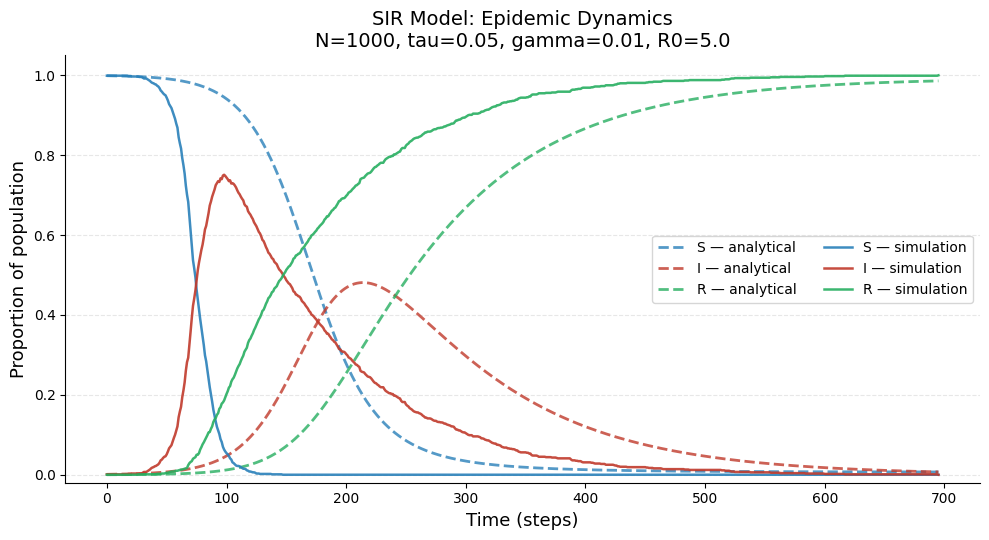

In [6]:
# Compute analytical curves
S_a, I_a, R_a = analytical_SIR(N, tau, gamma, init_infected, n_steps_sim)

fig, ax = plt.subplots(figsize=(10, 5.5))

time_steps = np.arange(n_steps_sim + 1)

# ── Analytical curves (dashed) ────────────────────────────────────────────────
ax.plot(time_steps, S_a, color="#2980b9", linewidth=2,
        linestyle="--", alpha=0.8, label="S — analytical")
ax.plot(time_steps, I_a, color="#c0392b", linewidth=2,
        linestyle="--", alpha=0.8, label="I — analytical")
ax.plot(time_steps, R_a, color="#27ae60", linewidth=2,
        linestyle="--", alpha=0.8, label="R — analytical")

# ── Simulation curves (solid) ─────────────────────────────────────────────────
ax.plot(time_steps, sim_data["proportion_susceptible"].values,
        color="#2980b9", linewidth=1.8, alpha=0.9, label="S — simulation")
ax.plot(time_steps, sim_data["proportion_infected"].values,
        color="#c0392b", linewidth=1.8, alpha=0.9, label="I — simulation")
ax.plot(time_steps, sim_data["proportion_removed"].values,
        color="#27ae60", linewidth=1.8, alpha=0.9, label="R — simulation")

ax.set_xlabel("Time (steps)", fontsize=13)
ax.set_ylabel("Proportion of population", fontsize=13)
ax.set_title(
    f"SIR Model: Epidemic Dynamics\n"
    f"N={N}, tau={tau}, gamma={gamma}, R0={tau/gamma:.1f}",
    fontsize=14,
)
ax.set_ylim(-0.02, 1.05)
ax.legend(fontsize=10, ncol=2, loc="center right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


---
## 7. The Epidemic Curve: Effect of τ

The "epidemic curve" — just the I compartment over time — is the most  
clinically meaningful output. It shows the rise and fall of active infections.

We sweep τ while holding γ fixed. As τ increases:
- The epidemic grows faster and peaks earlier
- The peak infection level is higher  
- More of the population is eventually infected (larger final R)
- **Flattening the curve** means reducing τ (e.g., via masks, distancing) to  
  keep the peak lower, even if the epidemic lasts longer

This directly illustrates the "flatten the curve" concept from public health.


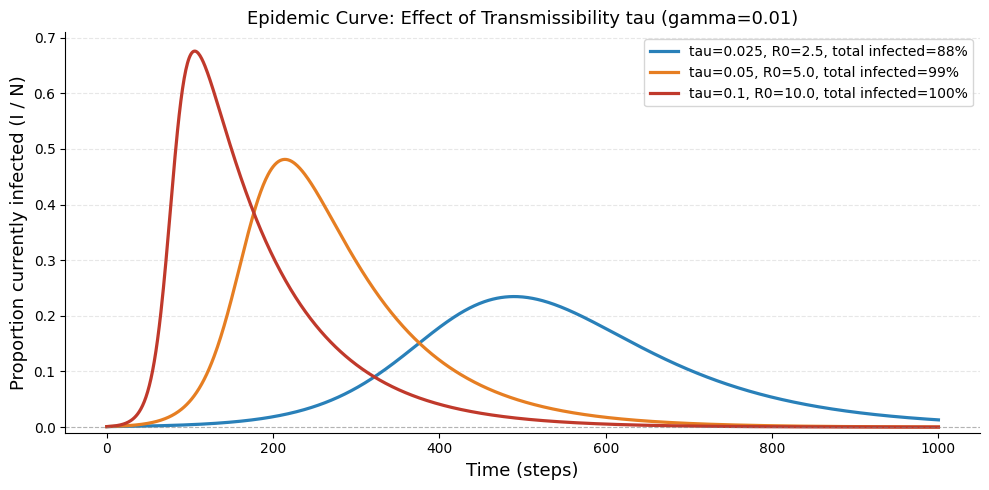

In [8]:
# GLOBAL VARIABLE: tau_values — transmissibility values to compare
tau_values = [0.025, 0.05, 0.1]
colors_tau  = ["#2980b9", "#e67e22", "#c0392b"]

fig, ax = plt.subplots(figsize=(10, 5))

for tau_val, color in zip(tau_values, colors_tau):
    # LOCAL VARIABLE: S_c, I_c, R_c — analytical curves for this tau
    S_c, I_c, R_c = analytical_SIR(N, tau_val, gamma, init_infected, n_steps=1000)

    r0_val    = tau_val / gamma
    final_inf = R_c[-1]

    ax.plot(
        I_c, color=color, linewidth=2.3,
        label=f"tau={tau_val}, R0={r0_val:.1f}, total infected={final_inf*100:.0f}%",
    )

# Reference line for peak detection
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--", alpha=0.5)

ax.set_xlabel("Time (steps)", fontsize=13)
ax.set_ylabel("Proportion currently infected (I / N)", fontsize=13)
ax.set_title(
    f"Epidemic Curve: Effect of Transmissibility tau (gamma={gamma})",
    fontsize=13,
)
ax.set_ylim(-0.01, None)
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


---
## 8. SIR vs. SIS: The Effect of the `remove_recovered` Switch

The book's model uses a single switch to toggle between SIS and SIR behavior.  
Our Python implementation inherits this directly through the `remove_recovered` parameter.

Running both modes with identical parameters reveals the fundamental difference:
- **SIS** (remove_recovered=False): infection oscillates around a dynamic equilibrium;  
  recovered agents re-enter the susceptible pool and can be infected again
- **SIR** (remove_recovered=True): the epidemic burns out completely;  
  recovered agents accumulate in R and are permanently removed from the dynamics


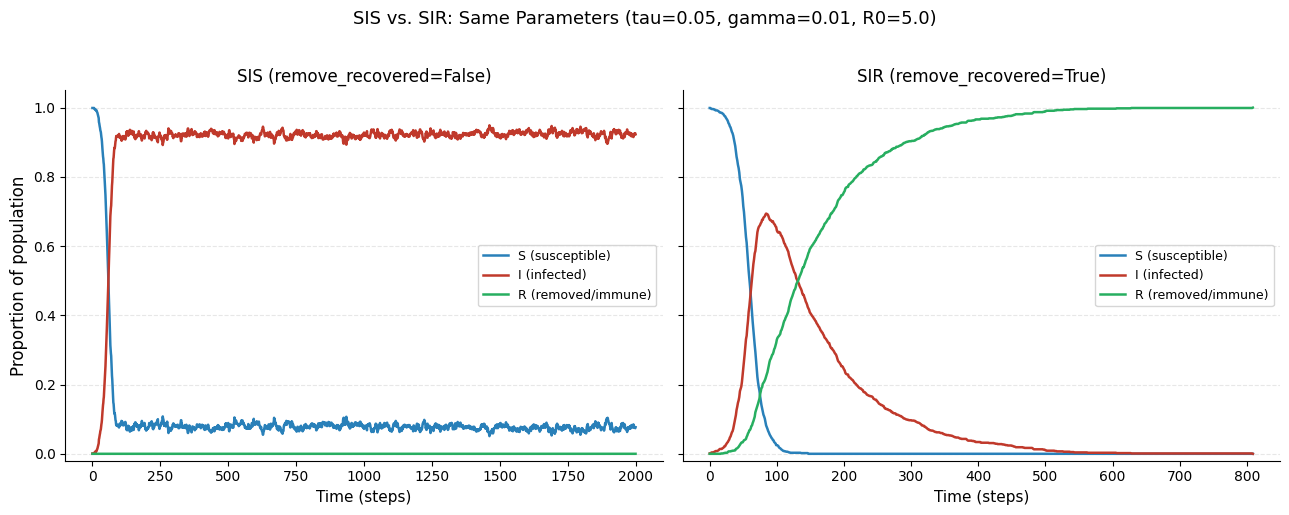

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

# ── Shared parameters ─────────────────────────────────────────────────────────
shared_params = dict(
    N=N, init_infected=init_infected, tau=tau, gamma=gamma,
    alpha=alpha, infection_radius=infection_radius,
    speed=speed, turning_angle=turning_angle,
)

for ax, remove_rec, title_suffix in zip(
    axes,
    [False, True],
    ["SIS (remove_recovered=False)", "SIR (remove_recovered=True)"],
):
    # LOCAL VARIABLE: m — one model run per mode
    m = SIRModel(**shared_params, remove_recovered=remove_rec)
    data = m.run(max_steps=2000)
    steps = len(data) - 1
    t = np.arange(steps + 1)

    ax.plot(t, data["proportion_susceptible"].values,
            color="#2980b9", linewidth=1.8, label="S (susceptible)")
    ax.plot(t, data["proportion_infected"].values,
            color="#c0392b", linewidth=1.8, label="I (infected)")
    ax.plot(t, data["proportion_removed"].values,
            color="#27ae60", linewidth=1.8, label="R (removed/immune)")

    ax.set_title(title_suffix, fontsize=12)
    ax.set_xlabel("Time (steps)", fontsize=11)
    ax.set_ylim(-0.02, 1.05)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.legend(fontsize=9)

axes[0].set_ylabel("Proportion of population", fontsize=12)
fig.suptitle(
    f"SIS vs. SIR: Same Parameters (tau={tau}, gamma={gamma}, R0={tau/gamma:.1f})",
    fontsize=13, y=1.02,
)

plt.tight_layout()
plt.show()


---
## 9. Final Epidemic Size as a Function of R₀

A key question for public health: **what fraction of the population will ultimately  
be infected** before the epidemic ends?

This "final size" is not 100% (the epidemic stops before infecting everyone),  
and it's not the SIS equilibrium either. It depends on R₀ in a non-linear way.

We compute the final size numerically from the analytical model for a range of R₀ values.

Key observations:
- When R₀ < 1: no epidemic — final size ≈ 0
- When R₀ just exceeds 1: a small outbreak occurs
- As R₀ grows: final size increases sharply at first, then more slowly
- At very high R₀: the final size approaches (but never quite reaches) 100%


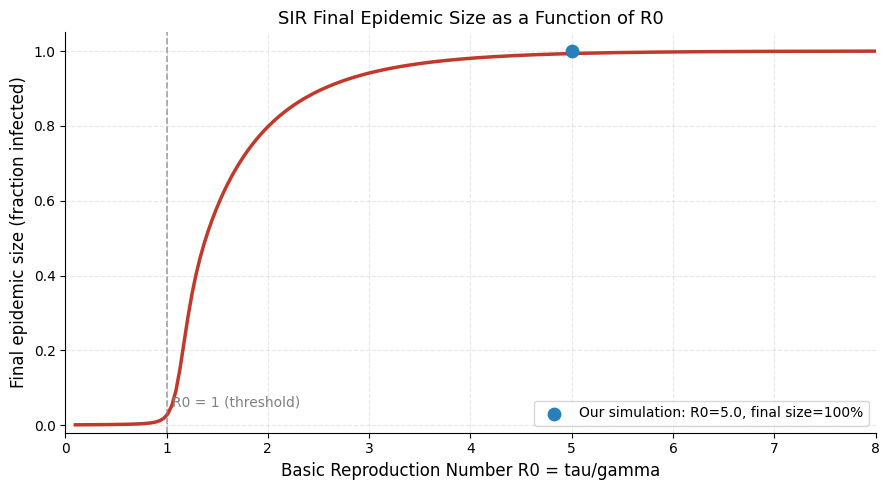

In [10]:
# Sweep tau values to vary R0 (keeping gamma fixed)
# LOCAL VARIABLE: tau_range — range of tau values
tau_range = np.linspace(0.001, 0.08, 200)

# LOCAL VARIABLE: final_sizes — fraction of population infected by end of epidemic
final_sizes = []

for tau_val in tau_range:
    _, _, R_curve = analytical_SIR(N=1000, tau=tau_val, gamma=gamma, I0=1, n_steps=3000)
    final_sizes.append(R_curve[-1])

# Convert tau to R0 for the x-axis
R0_range = tau_range / gamma

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(R0_range, final_sizes, color="#c0392b", linewidth=2.5)
ax.axvline(1.0, color="grey", linewidth=1.2, linestyle="--", alpha=0.7)
ax.text(1.05, 0.05, "R0 = 1 (threshold)", color="grey", fontsize=10)

# Mark our default simulation's R0
ax.scatter(
    [tau / gamma], [sim_data["proportion_removed"].iloc[-1]],
    color="#2980b9", s=80, zorder=5,
    label=f"Our simulation: R0={tau/gamma:.1f}, final size={sim_data['proportion_removed'].iloc[-1]*100:.0f}%",
)

ax.set_xlabel("Basic Reproduction Number R0 = tau/gamma", fontsize=12)
ax.set_ylabel("Final epidemic size (fraction infected)", fontsize=12)
ax.set_title("SIR Final Epidemic Size as a Function of R0", fontsize=13)
ax.set_ylim(-0.02, 1.05)
ax.set_xlim(0, R0_range.max())
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="both", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


---
## 10. Reflection and Key Takeaways

### The full family of models in Chapter 4

| Model | States | Recovery --> | Epidemic ends? | Long-run state |
|---|---|---|---|---|
| Spontaneous | S, I | — | ✅ Yes (everyone infected) | 100% I |
| SI | S, I | — | ✅ Yes (everyone infected) | 100% I |
| SIS | S, I | --> S (susceptible again) | ❌ No (equilibrium) | I*/N = 1 − γ/τ |
| **SIR** | S, I, R | --> R (permanent immunity) | ✅ Yes (burnout) | I=0, S+R=1 |

### The three insights unique to SIR

1. **The epidemic always ends, but not because everyone is infected.**  
   The growing R pool depletes S fast enough that I can no longer grow.  
   Some susceptibles survive — they were just never exposed in time.

2. **Herd immunity is an emergent property.**  
   The epidemic stops when the R pool is large enough that an infected agent  
   is more likely to encounter an immune person than a susceptible one.  
   This is the same threshold $V^* = 1 - 1/R_0$ derived analytically in Section 4.5.3,  
   but here it emerges from the dynamics rather than being enforced by vaccination.

3. **The epidemic curve is the central public health object.**  
   Its height (peak infections) determines whether health systems are overwhelmed.  
   Its width determines how long the epidemic lasts.  
   Reducing τ (transmissibility) flattens and broadens the curve without  
   changing the total number who get infected — it just spreads it out over time.

### Model assumptions to keep in mind

The book closes by reminding us that R₀ and these predictions rest on:
- Perfectly well-mixed populations (no geography, no social network structure)
- No behavioral change during the epidemic
- Perfectly effective immunity
- Identical individuals

All of these are violated in real outbreaks which is why agent-based models  
that relax these assumptions (later chapters) are so valuable.
